# EDA — Visão Geral do Dataset Olist

**Objetivo:** Entender a estrutura, qualidade e volumetria dos dados antes de qualquer modelagem.  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)  
**Autor:** Josafa Barbosa  
**Data:** Abril 2026

---

## Contexto de Negócio

O dataset Olist representa transações reais de um marketplace brasileiro entre 2016 e 2018.
Contém ~100k pedidos com informações de clientes, produtos, vendedores, pagamentos e avaliações.

Este notebook responde às perguntas iniciais:
- Quantos registros e colunas tem cada tabela?
- Qual a qualidade dos dados (nulos, tipos, duplicatas)?
- Como as tabelas se relacionam entre si?

In [2]:
# Importações
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurações de visualização
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

# Caminho base dos dados — relativo à raiz do projeto
DATA_RAW = Path('data/raw')

# Carregamento de todas as tabelas
tabelas = {
    'orders':       pd.read_csv(DATA_RAW / 'olist_orders_dataset.csv'),
    'order_items':  pd.read_csv(DATA_RAW / 'olist_order_items_dataset.csv'),
    'payments':     pd.read_csv(DATA_RAW / 'olist_order_payments_dataset.csv'),
    'reviews':      pd.read_csv(DATA_RAW / 'olist_order_reviews_dataset.csv'),
    'customers':    pd.read_csv(DATA_RAW / 'olist_customers_dataset.csv'),
    'sellers':      pd.read_csv(DATA_RAW / 'olist_sellers_dataset.csv'),
    'products':     pd.read_csv(DATA_RAW / 'olist_products_dataset.csv'),
    'category':     pd.read_csv(DATA_RAW / 'product_category_name_translation.csv'),
    'geolocation':  pd.read_csv(DATA_RAW / 'olist_geolocation_dataset.csv'),
}

print('Tabelas carregadas:', list(tabelas.keys()))

Tabelas carregadas: ['orders', 'order_items', 'payments', 'reviews', 'customers', 'sellers', 'products', 'category', 'geolocation']


## 1. Volumetria das Tabelas

Quantos registros e colunas tem cada tabela? Esta é a primeira pergunta antes de qualquer análise.

In [3]:
# Resumo de volumetria: linhas e colunas por tabela
resumo = pd.DataFrame([
    {
        'tabela': nome,
        'linhas': df.shape[0],
        'colunas': df.shape[1],
        'memoria_mb': round(df.memory_usage(deep=True).sum() / 1024**2, 2)
    }
    for nome, df in tabelas.items()
]).sort_values('linhas', ascending=False).reset_index(drop=True)

resumo

,tabela,linhas,colunas,memoria_mb
0,geolocation,1000163,5,145.20
1,order_items,112650,7,39.43
2,payments,103886,5,17.81
3,orders,99441,8,58.97
4,customers,99441,5,29.62
5,reviews,99224,7,42.75
6,products,32951,9,6.79
7,sellers,3095,4,0.66
8,category,71,2,0.01


## 2. Qualidade dos Dados — Valores Nulos

Identificar colunas com dados ausentes em cada tabela para decidir estratégia de tratamento.

In [5]:
# Análise de nulos por tabela — apenas colunas com nulos
print("=== COLUNAS COM VALORES NULOS ===\n")

for nome, df in tabelas.items():
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    if len(nulos) > 0:
        pct = (nulos / len(df) * 100).round(1)
        resumo_nulos = pd.DataFrame({'nulos': nulos, 'pct_%': pct})
        print(f"📋 {nome.upper()}")
        print(resumo_nulos.to_string())
        print()

=== COLUNAS COM VALORES NULOS ===

📋 ORDERS
                               nulos  pct_%
order_approved_at                160    0.2
order_delivered_carrier_date    1783    1.8
order_delivered_customer_date   2965    3.0

📋 REVIEWS
                        nulos  pct_%
review_comment_title    87656   88.3
review_comment_message  58247   58.7

📋 PRODUCTS
                            nulos  pct_%
product_category_name         610    1.9
product_name_lenght           610    1.9
product_description_lenght    610    1.9
product_photos_qty            610    1.9
product_weight_g                2    0.0
product_length_cm               2    0.0
product_height_cm               2    0.0
product_width_cm                2    0.0



## 3. Análise de Tipos de Dados

Verificar se datas estão como string, IDs como objeto e valores numéricos corretos.
Colunas de data precisam ser convertidas antes de qualquer cálculo de prazo ou coorte.

In [6]:
# Tipos de dados por tabela — foco em colunas de data e valor
print("=== TIPOS DE DADOS — COLUNAS CRÍTICAS ===\n")

for nome, df in tabelas.items():
    print(f"📋 {nome.upper()}")
    print(df.dtypes.to_string())
    print()

=== TIPOS DE DADOS — COLUNAS CRÍTICAS ===

📋 ORDERS
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str

📋 ORDER_ITEMS
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64

📋 PAYMENTS
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64

📋 REVIEWS
review_id                    str
order_id                     str
review_score               int64
review_comment_title         str
review_comment_message       str
review_creation_date         str
review_answer_timestamp      str

📋 CUS

## 4. Distribuição de Status dos Pedidos

Qual o volume de pedidos por status? Isso define o universo analisável
e revela a taxa real de cancelamento no período.

C:\Users\JosafaBarbosadosSant\AppData\Local\Temp\ipykernel_58192\2509370800.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=status, x='status', y='quantidade', palette='Blues_d', ax=ax)


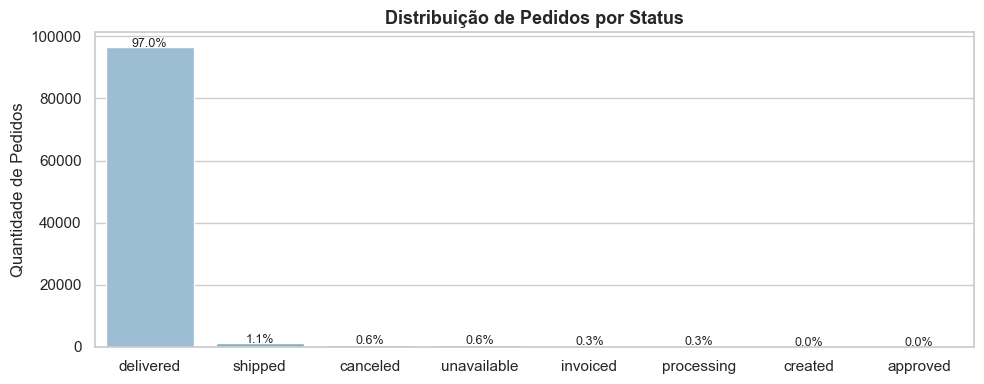

     status  quantidade  pct_%
  delivered       96478   97.0
    shipped        1107    1.1
   canceled         625    0.6
unavailable         609    0.6
   invoiced         314    0.3
 processing         301    0.3
    created           5    0.0
   approved           2    0.0


In [7]:
# Distribuição de status dos pedidos
status = (
    tabelas['orders']['order_status']
    .value_counts()
    .reset_index()
    .rename(columns={'order_status': 'status', 'count': 'quantidade'})
)
status['pct_%'] = (status['quantidade'] / status['quantidade'].sum() * 100).round(1)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=status, x='status', y='quantidade', palette='Blues_d', ax=ax)
ax.set_title('Distribuição de Pedidos por Status', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Quantidade de Pedidos')

for i, row in status.iterrows():
    ax.text(i, row['quantidade'] + 200, f"{row['pct_%']}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(status.to_string(index=False))

## 5. Evolução Temporal dos Pedidos

Quando o Olist cresceu? Identificar sazonalidade e o período de dados disponível
é essencial para definir o recorte temporal do dashboard estratégico.

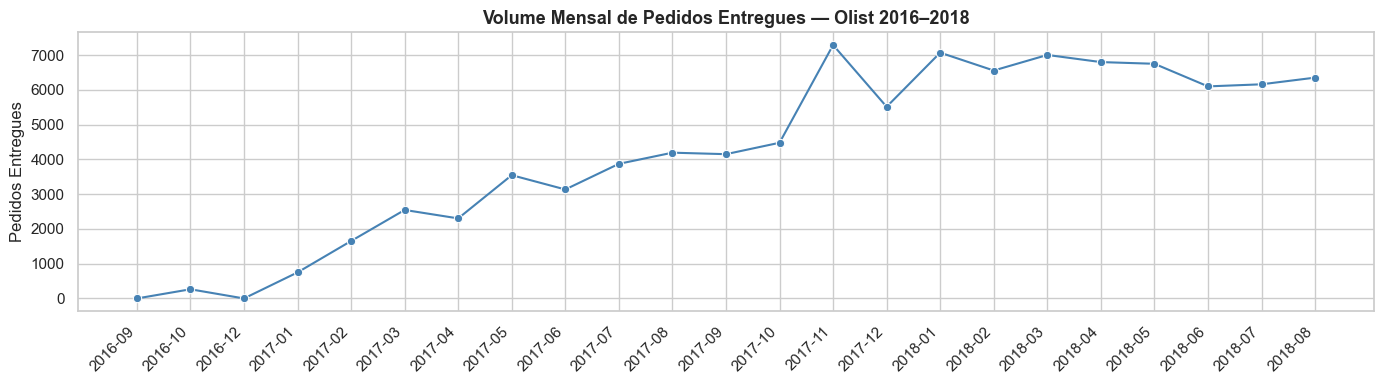

Período: 2016-09 a 2018-08
Pico mensal: 7289 pedidos em 2017-11


In [8]:
import warnings
warnings.filterwarnings('ignore')

# Converter data de compra para datetime
orders = tabelas['orders'].copy()
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['mes_ano'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Pedidos entregues por mês
evolucao = (
    orders[orders['order_status'] == 'delivered']
    .groupby('mes_ano')
    .size()
    .reset_index(name='pedidos')
)
evolucao['mes_ano_str'] = evolucao['mes_ano'].astype(str)

# Gráfico
fig, ax = plt.subplots(figsize=(14, 4))
sns.lineplot(data=evolucao, x='mes_ano_str', y='pedidos', marker='o', color='steelblue', ax=ax)
ax.set_title('Volume Mensal de Pedidos Entregues — Olist 2016–2018', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Pedidos Entregues')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Período: {evolucao['mes_ano_str'].min()} a {evolucao['mes_ano_str'].max()}")
print(f"Pico mensal: {evolucao['pedidos'].max()} pedidos em {evolucao.loc[evolucao['pedidos'].idxmax(), 'mes_ano_str']}")

## 6. Mapa de Relacionamento entre Tabelas

Chaves primárias e estrangeiras que conectam as 9 tabelas do Olist.
Esta estrutura orienta a modelagem semântica na camada dbt.

In [10]:
# Verificação de integridade referencial — chave central: order_id
order_ids = set(tabelas['orders']['order_id'])

verificacoes = {
    'order_items':  tabelas['order_items']['order_id'],
    'payments':     tabelas['payments']['order_id'],
    'reviews':      tabelas['reviews']['order_id'],
}

print("=== INTEGRIDADE REFERENCIAL — order_id ===\n")
for tabela, coluna in verificacoes.items():
    ids_tabela = set(coluna)
    orfaos = ids_tabela - order_ids
    cobertura = len(ids_tabela & order_ids) / len(order_ids) * 100
    print(f"{tabela:15} | registros: {len(coluna):6} | cobertura orders: {cobertura:.1f}% | órfãos: {len(orfaos)}")

print("\n=== RESUMO DO MODELO RELACIONAL ===")
print("""
orders (fato central)
  ├── order_items   → via order_id  (itens do pedido, produto, vendedor, preço)
  ├── payments      → via order_id  (forma de pagamento, valor, parcelas)
  ├── reviews       → via order_id  (nota, comentário, timestamp)
  └── customers     → via customer_id

products → via product_id em order_items
sellers  → via seller_id  em order_items
category → via product_category_name em products
geolocation → enriquecimento via zip_code (customers e sellers)
""")

=== INTEGRIDADE REFERENCIAL — order_id ===

order_items     | registros: 112650 | cobertura orders: 99.2% | órfãos: 0
payments        | registros: 103886 | cobertura orders: 100.0% | órfãos: 0
reviews         | registros:  99224 | cobertura orders: 99.2% | órfãos: 0

=== RESUMO DO MODELO RELACIONAL ===

orders (fato central)
  ├── order_items   → via order_id  (itens do pedido, produto, vendedor, preço)
  ├── payments      → via order_id  (forma de pagamento, valor, parcelas)
  ├── reviews       → via order_id  (nota, comentário, timestamp)
  └── customers     → via customer_id

products → via product_id em order_items
sellers  → via seller_id  em order_items
category → via product_category_name em products
geolocation → enriquecimento via zip_code (customers e sellers)



## Conclusões da Visão Geral

| Achado | Impacto no Dashboard |
|--------|---------------------|
| 97% de pedidos entregues | Base analisável robusta |
| Crescimento 20x em 2 anos | Tendência temporal é KPI principal |
| 0,6% de cancelamentos | Taxa baixa mas geograficamente investigável |
| 88% de reviews sem comentário | NPS baseado apenas em score numérico |
| 610 produtos sem categoria | Tratamento obrigatório antes do ROI por categoria |
| Todas as datas como string | Conversão obrigatória na camada de limpeza (v0.3) |
| Integridade referencial 99–100% | Joins confiáveis para a camada dbt |